In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Question 4

Nous pouvons considéré un seul véhicule car ils ont tous la même charge maximale et le même $\beta$.

On a $\forall i \in [0; N-1], Q_{i+1} = Q_i + \Delta t\beta P_i$

Ainsi : $\forall i \in [0; N-1], \beta P_i = (SOC_{i+1}-SOC_i)Q_{barre}/\Delta t$ qui va constituer notre problème des moindres carrés. 

In [ ]:
#Question 5

data = pd.read_csv("data_battery.csv")

U_sec = 230
Q_barre = 50*3600

time = np.array(data["Time [s]"])

list_A = np.array(U_sec*data["I [kA]"])
A = list_A[:len(list_A)-1]
A = A.reshape((len(A), 1))

SOC = np.array(data["SOC [%]"])
b = (SOC[1:]-SOC[:len(SOC)-1])*Q_barre/(time[1:]-time[:len(time)-1])
b = b.reshape((len(b),1))
#Beta = (A^T*A)^{-1}*(A^T*b)
beta = np.linalg.lstsq(A, b)

print(beta)

(array([[2.98290823]]), array([24972005.44733315]), np.int32(1), array([2159.59040127]))


In [39]:
#Si on filtre le bruit (moyenne glissante sur 3 termes)

intensite_filtre = data["I [kA]"].rolling(3)
intensite_filtre


Rolling [window=3,center=False,axis=0,method=single]

In [21]:
print(A.shape[-2:])

(298, 1)


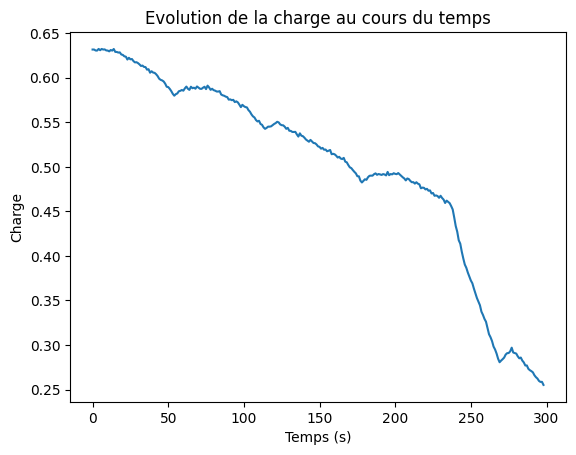

In [45]:
data["SOC [%]"].plot(x="time (s)", y="charge", title = "Evolution de la charge au cours du temps")
plt.xlabel("Temps (s)")
plt.ylabel("Charge")
plt.show()